In [1]:
import numpy as np
import matplotlib.pyplot as plt


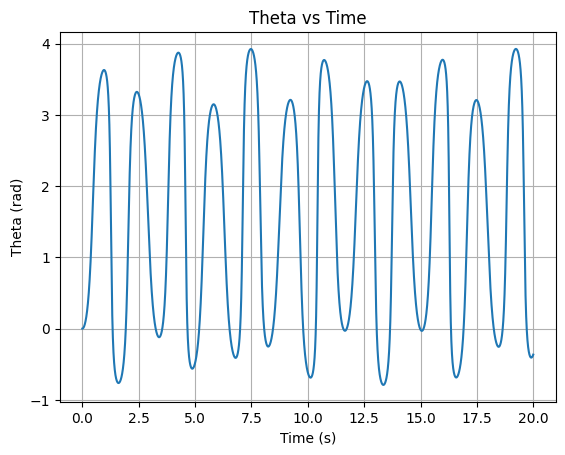

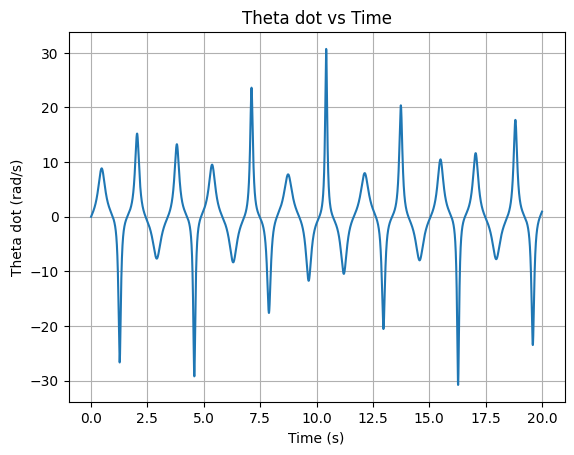

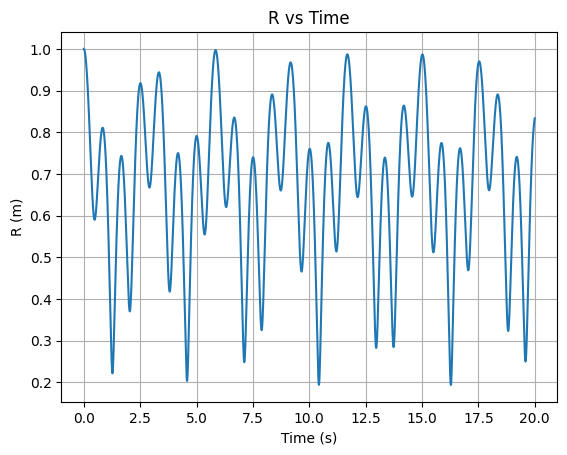

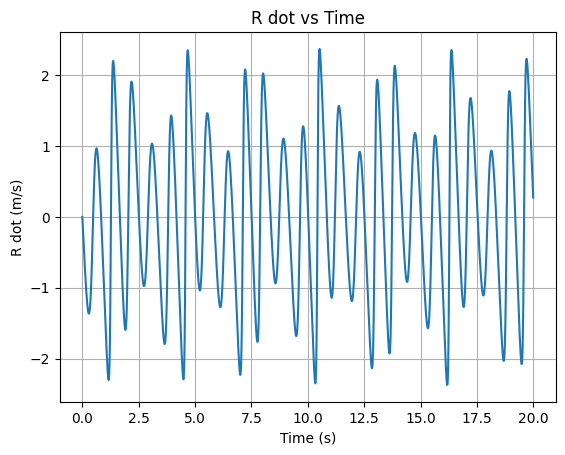

In [ ]:
# calculating and plotting theta, thetadot, r vs time, rdot vs time, for a pendulum-mass-pulley system

# vary later
m = 1
M = 2

massRatio = m / M

g = 9.81  # m/s^2
Thetainitial = 0 # in radians
Thetadotinitial = 0  # in rad/s
thetadotdotinitial = 0  # in rad/s^2
Rinitial = 1  # in m
Rdotinitial = 0  # in m/s
rdotdotinitial = 0  # in m/s^2

tfinal = 20  # seconds
dt = 0.00001  # seconds
nsteps = int(tfinal / dt)
time = np.linspace(0, tfinal, nsteps)

# arrays to hold values
theta = np.zeros(nsteps)
thetadot = np.zeros(nsteps)
thetadotdot = np.zeros(nsteps)
r = np.zeros(nsteps)
rdot = np.zeros(nsteps)
rdotdot = np.zeros(nsteps)


# initial conditions
theta[0] = Thetainitial
thetadot[0] = Thetadotinitial
thetadotdot[0] = thetadotdotinitial
r[0] = Rinitial
rdot[0] = Rdotinitial
rdotdot[0] = rdotdotinitial


# main solver loop
for i in range(nsteps - 1):

    # coupled equations of motion using finite difference method
    rdotdot[i] = (m * r[i] * thetadot[i]**2 - g * (M - m * np.sin(theta[i]))) / (m + M)
    
    r[i] = max(1e-6, r[i])  # prevent r from going to zero or negative
    thetadotdot[i] = (g * np.cos(theta[i]) - 2 * rdot[i] * thetadot[i]) / r[i]

    # update values
    rdot[i + 1] = rdot[i] + rdotdot[i] * dt
    r[i + 1] = r[i] + rdot[i + 1] * dt
    r[i + 1] = max(1e-6, r[i + 1])  # prevent r from going to zero or negative
    thetadot[i + 1] = thetadot[i] + thetadotdot[i] * dt
    
    theta[i + 1] = theta[i] + thetadot[i + 1] * dt


# plotting results
plt.plot(time, theta)
plt.title('Theta vs Time')
plt.xlabel('Time (s)')
plt.ylabel('Theta (rad)')
plt.grid()
plt.savefig('theta_vs_time.png')
plt.show()

plt.plot(time, thetadot)
plt.title('Theta dot vs Time')
plt.xlabel('Time (s)')
plt.ylabel('Theta dot (rad/s)')
plt.grid()
plt.savefig('thetadot_vs_time.png')
plt.show()

plt.plot(time, r / Rinitial)
plt.title('R vs Time')
plt.xlabel('Time (s)')
plt.ylabel('R (m)')
plt.grid()
plt.savefig('r_vs_time.png')
plt.show()

plt.plot(time, rdot/Rinitial)
plt.title('R dot vs Time')
plt.xlabel('Time (s)')
plt.ylabel('R dot (m/s)')
plt.grid()
plt.savefig('rdot_vs_time.png')
plt.show()